In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [4]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3

BATCH_SIZE = 8

CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"] # [0, 1, 2, 3, 4]

In [5]:
def read_and_decode(filename, resize_dims):
    
    # reading raw file
    img_bytes = tf.io.read_file(filename)
    
    # decode image data
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    
    # converting pixel values into float in [0 1]
    img = tf.image.convert_image_dtype(img, tf.float32)
    
    # resize image to match desired dimensions
    img = tf.image.resize(img, resize_dims)
    
    return img

In [6]:
def parse_csvline(csv_line):
    # record_defaults specify the data types for each column
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    # Load the image
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

    # Convert label string to integer based on the CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [7]:
import pathlib
import tensorflow as tf

# 1. Download the raw dataset directly to Kaggle
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
import pathlib

# 1. Fix the nested directory bug
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'
    
print("Using dataset path:", data_dir)

Using dataset path: /root/.keras/datasets/flower_photos/flower_photos


In [9]:
# 2. Rebuild the datasets with the correct path
train_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

eval_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


I0000 00:00:1784798905.151995      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [10]:
# 3. Apply the performance caching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
eval_dataset = eval_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
for image_batch, label_batch in train_dataset.take(3):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (8, 128, 128, 3)
Label batch shape: (8,)
Labels: [3 1 4 3 1 2 1 2]
Image batch shape: (8, 128, 128, 3)
Label batch shape: (8,)
Labels: [4 1 3 4 2 4 4 3]
Image batch shape: (8, 128, 128, 3)
Label batch shape: (8,)
Labels: [0 4 1 3 1 1 2 3]


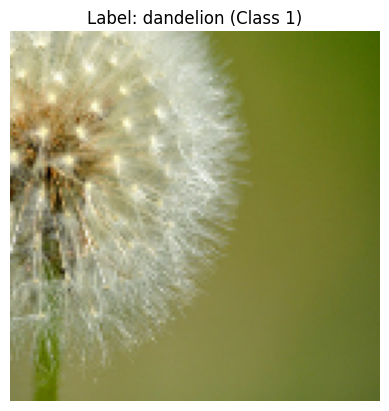

In [12]:
import matplotlib.pyplot as plt

# Take just one batch from the dataset
for image_batch, label_batch in train_dataset.take(1):
    
    # 1. Grab the first image and convert it to integers to fix the warning
    single_image = image_batch[0].numpy().astype("uint8")
    
    # 2. Grab the first label and look it up in our list
    label_index = label_batch[0].numpy()
    
    # FIX: Use 'class_name' so we do not overwrite the 'CLASS_NAMES' list
    class_name = CLASS_NAMES[label_index]
    
    # 3. Show the image and set the title
    plt.imshow(single_image)
    
    # FIX: Update the f-string to use the new 'class_name' variable
    plt.title(f"Label: {class_name} (Class {label_index})")
    plt.axis("off") # Hides the gridlines
    plt.show()

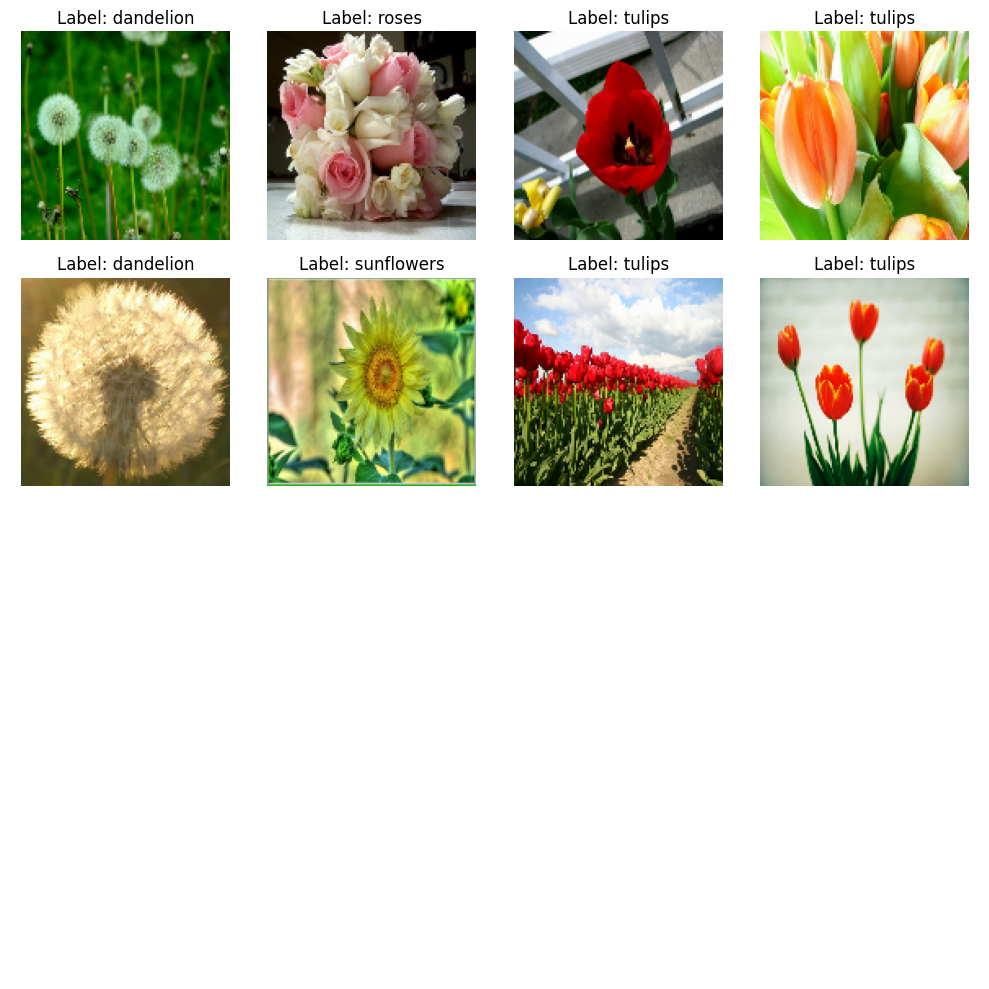

In [13]:
import matplotlib.pyplot as plt

# Take one batch from the dataset
for image_batch, label_batch in train_dataset.take(1):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))  # Create a 4x4 grid
    
    # Dynamically get the actual number of images in this batch
    num_images = len(image_batch)

    for i in range(16):  # Still loop 16 times to cover the whole 4x4 grid
        ax = axes[i // 4, i % 4]  # Determine grid position
        
        # Only try to plot if an image actually exists at this index
        if i < num_images:
            ax.imshow(image_batch[i].numpy().astype("uint8")) 
            ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
            
        ax.axis("off")  # Hide axes for all grid spots (even the empty ones)

    plt.tight_layout()
    plt.show()

# transfer learning without fine tuning

In [14]:
# Build model
base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
        include_top=False,    # Remove ImageNet head
        weights="imagenet"    # Use pretrained weights
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
base_model.trainable = False  # Freeze base

In [16]:
model = keras.Sequential([
    # 1. Add the Input layer to formally build the model
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    
    # 2. Rescale the pixels for MobileNetV2
    keras.layers.Rescaling(1./127.5, offset=-1),
    
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

In [17]:
# Compile model
model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
)

In [18]:
# Visualize model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

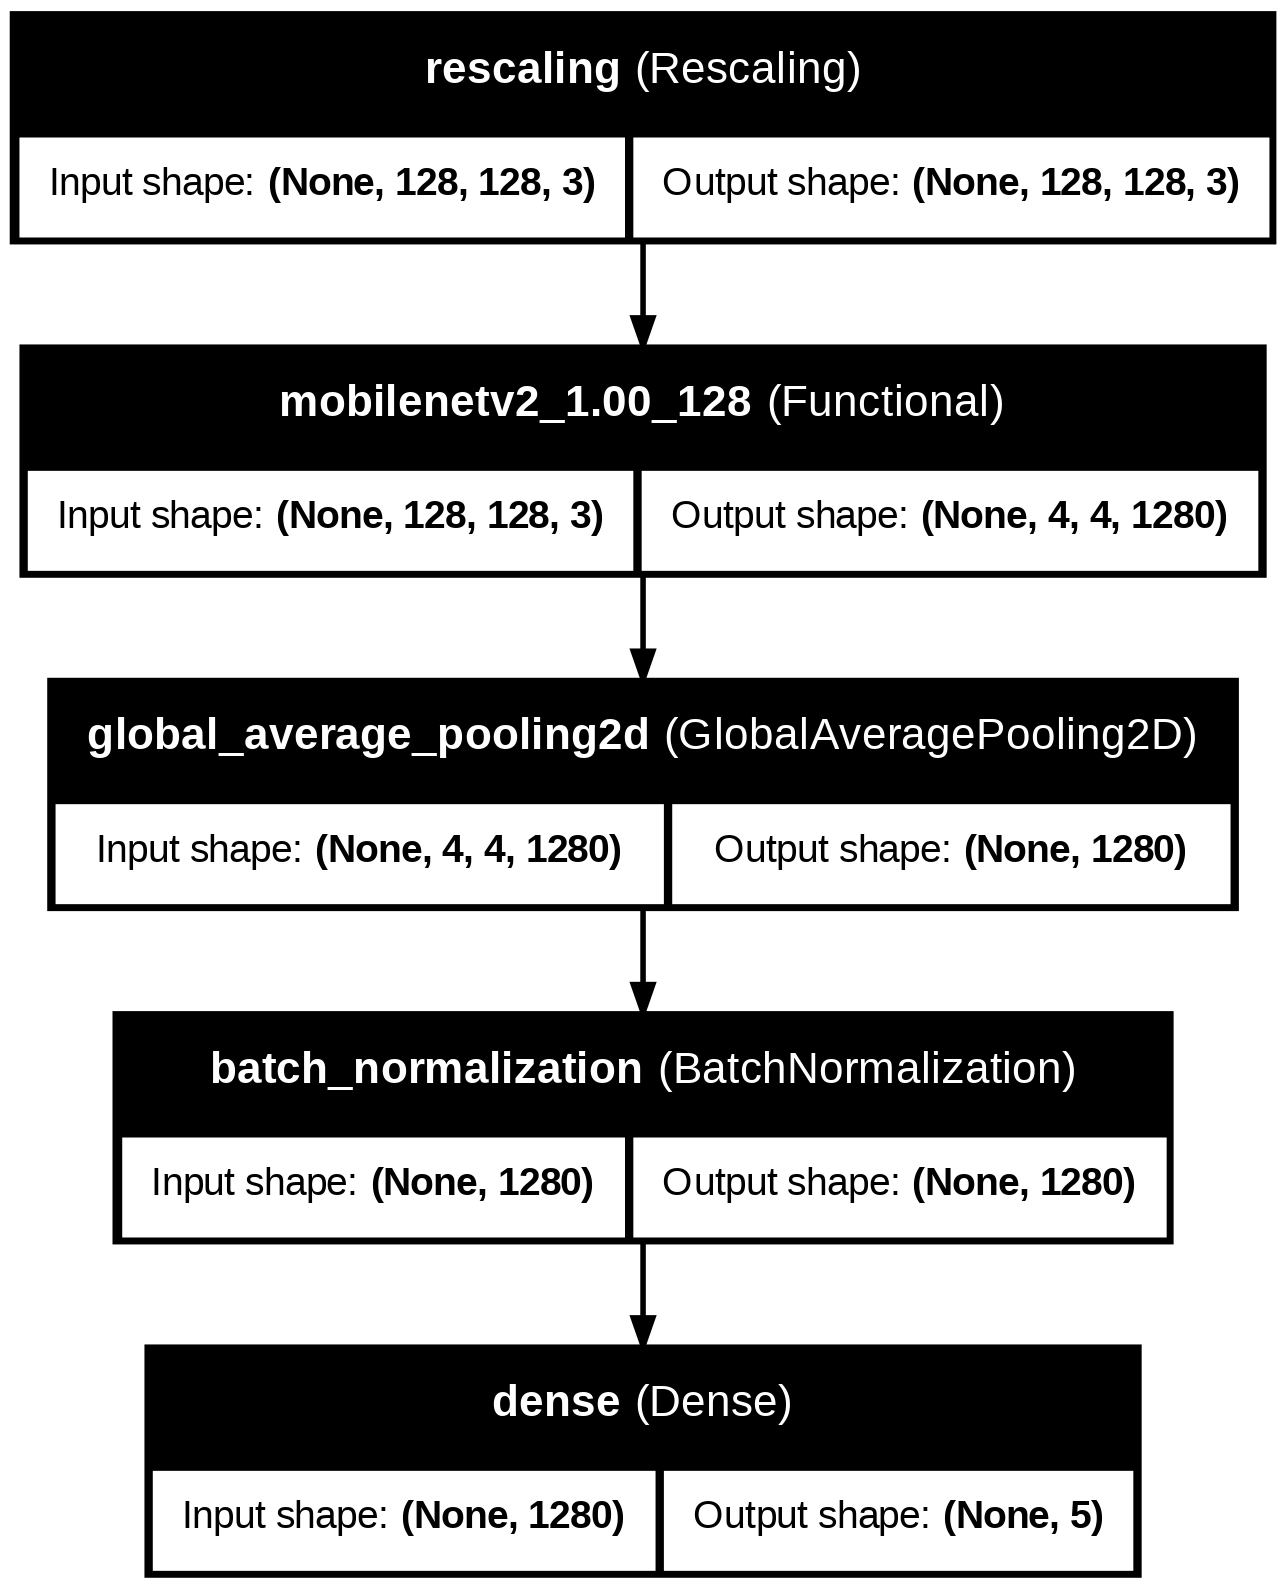

In [19]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file="model_visualization.png")

In [20]:
# Train the model and save the output to 'history'
history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10
)

Epoch 1/10


I0000 00:00:1784798924.642827     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


367/367 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.4751 - loss: 1.4066 - val_accuracy: 0.6717 - val_loss: 0.9241
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7166 - loss: 0.7946 - val_accuracy: 0.7738 - val_loss: 0.6855
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7732 - loss: 0.6413 - val_accuracy: 0.7943 - val_loss: 0.5853
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8052 - loss: 0.5600 - val_accuracy: 0.8120 - val_loss: 0.5316
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8239 - loss: 0.5048 - val_accuracy: 0.8229 - val_loss: 0.4986
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8392 - loss: 0.4626 - val_accuracy: 0.8297 - val_loss: 0.4765
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8525 - loss: 0.4282 - val_accuracy: 0.8351 - val_loss: 0.4610
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8617 - loss: 0.3989 - val_accuracy: 0.8447 - va

In [21]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(eval_dataset)

# Print the result nicely formatted as a percentage
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8515 - loss: 0.4349
Final Validation Accuracy: 85.15%


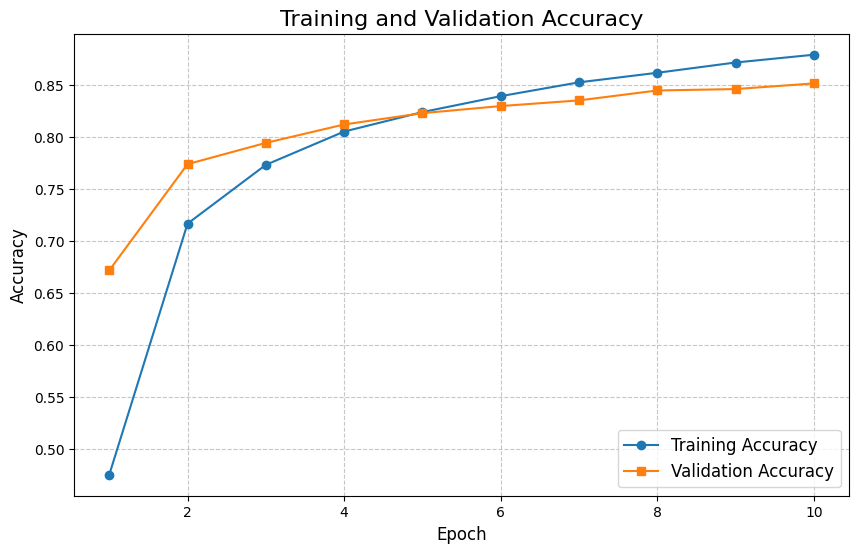

In [22]:
import matplotlib.pyplot as plt

# Extract the metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1) # This sets the x-axis to start at 1

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')

# Add labels and styling
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# transfer learning with fine tuning

In [23]:
# 1. Unfreeze the base model so its weights can be updated
base_model.trainable = True

In [24]:
# 2. Recompile the model 
# CRITICAL: We use a much lower learning rate (1e-5) so we don't wreck the pre-trained weights!
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [25]:
# Visualize the updated model (Notice the 'Trainable params' at the bottom has massively increased!)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

In [26]:
history_fine_tuning = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7326 - loss: 0.7213 - val_accuracy: 0.8610 - val_loss: 0.3921
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9373 - loss: 0.2651 - val_accuracy: 0.8610 - val_loss: 0.3877
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9922 - loss: 0.1239 - val_accuracy: 0.8692 - val_loss: 0.3966
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9997 - loss: 0.0692 - val_accuracy: 0.8665 - val_loss: 0.4104
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 1.0000 - loss: 0.0451 - val_accuracy: 0.8651 - val_loss: 0.4208
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 1.0000 - loss: 0.0317 - val_accuracy: 0.8610 - val_loss: 0.4298
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 0.8583 - val_loss: 0.4350
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 1.0000 - loss: 0.0177 - val_acc

In [27]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(eval_dataset)

# Print the result nicely formatted as a percentage
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8624 - loss: 0.4419
Final Validation Accuracy: 86.24%


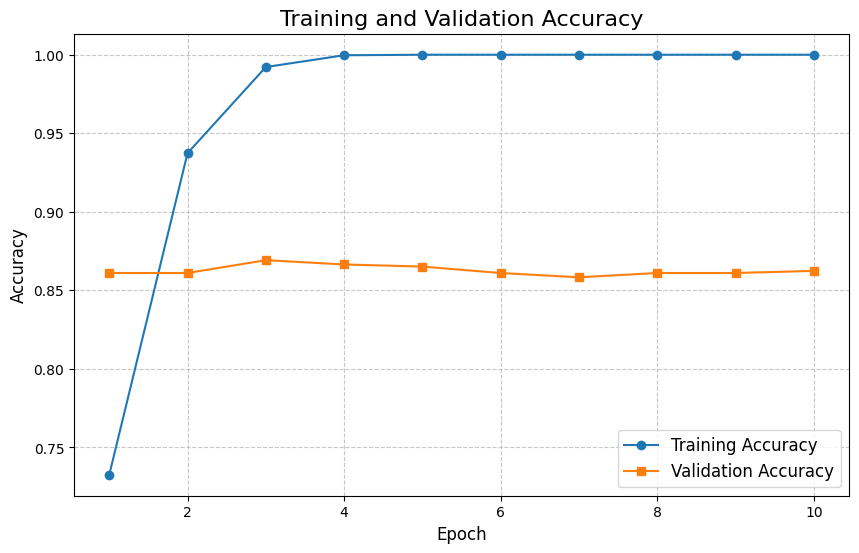

In [28]:
# Extract the metrics from the history object
acc = history_fine_tuning.history['accuracy']
val_acc = history_fine_tuning.history['val_accuracy']
epochs_range = range(1, len(acc) + 1) # This sets the x-axis to start at 1

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')

# Add labels and styling
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Transfer learning with fine-tuning + learning rate rescheduling

In [29]:
# 1. Build base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,    # Remove ImageNet head
    weights="imagenet"    # Use pretrained weights
)
base_model.trainable = True  # Unfreeze base for fine-tuning

In [30]:
# 2. Build full model
model = keras.Sequential([
    # Add Input layer to prevent the plot_model ValueError
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    # Add Rescaling so pixels are formatted correctly for MobileNetV2
    keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),       
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

In [31]:
# 3. Setup Learning Rate Schedule
initial_learning_rate = 0.0001 

In [32]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)

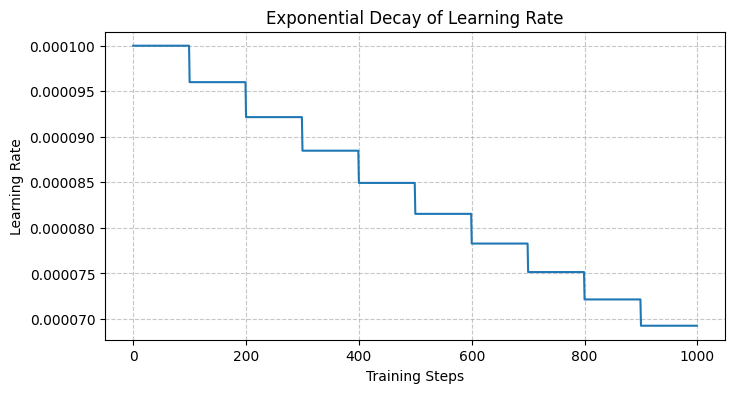

In [33]:
# Plot the decay
steps = np.arange(0, 1000)
lrs = [lr_schedule(step).numpy() for step in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs)
plt.title("Exponential Decay of Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [34]:
# 4. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

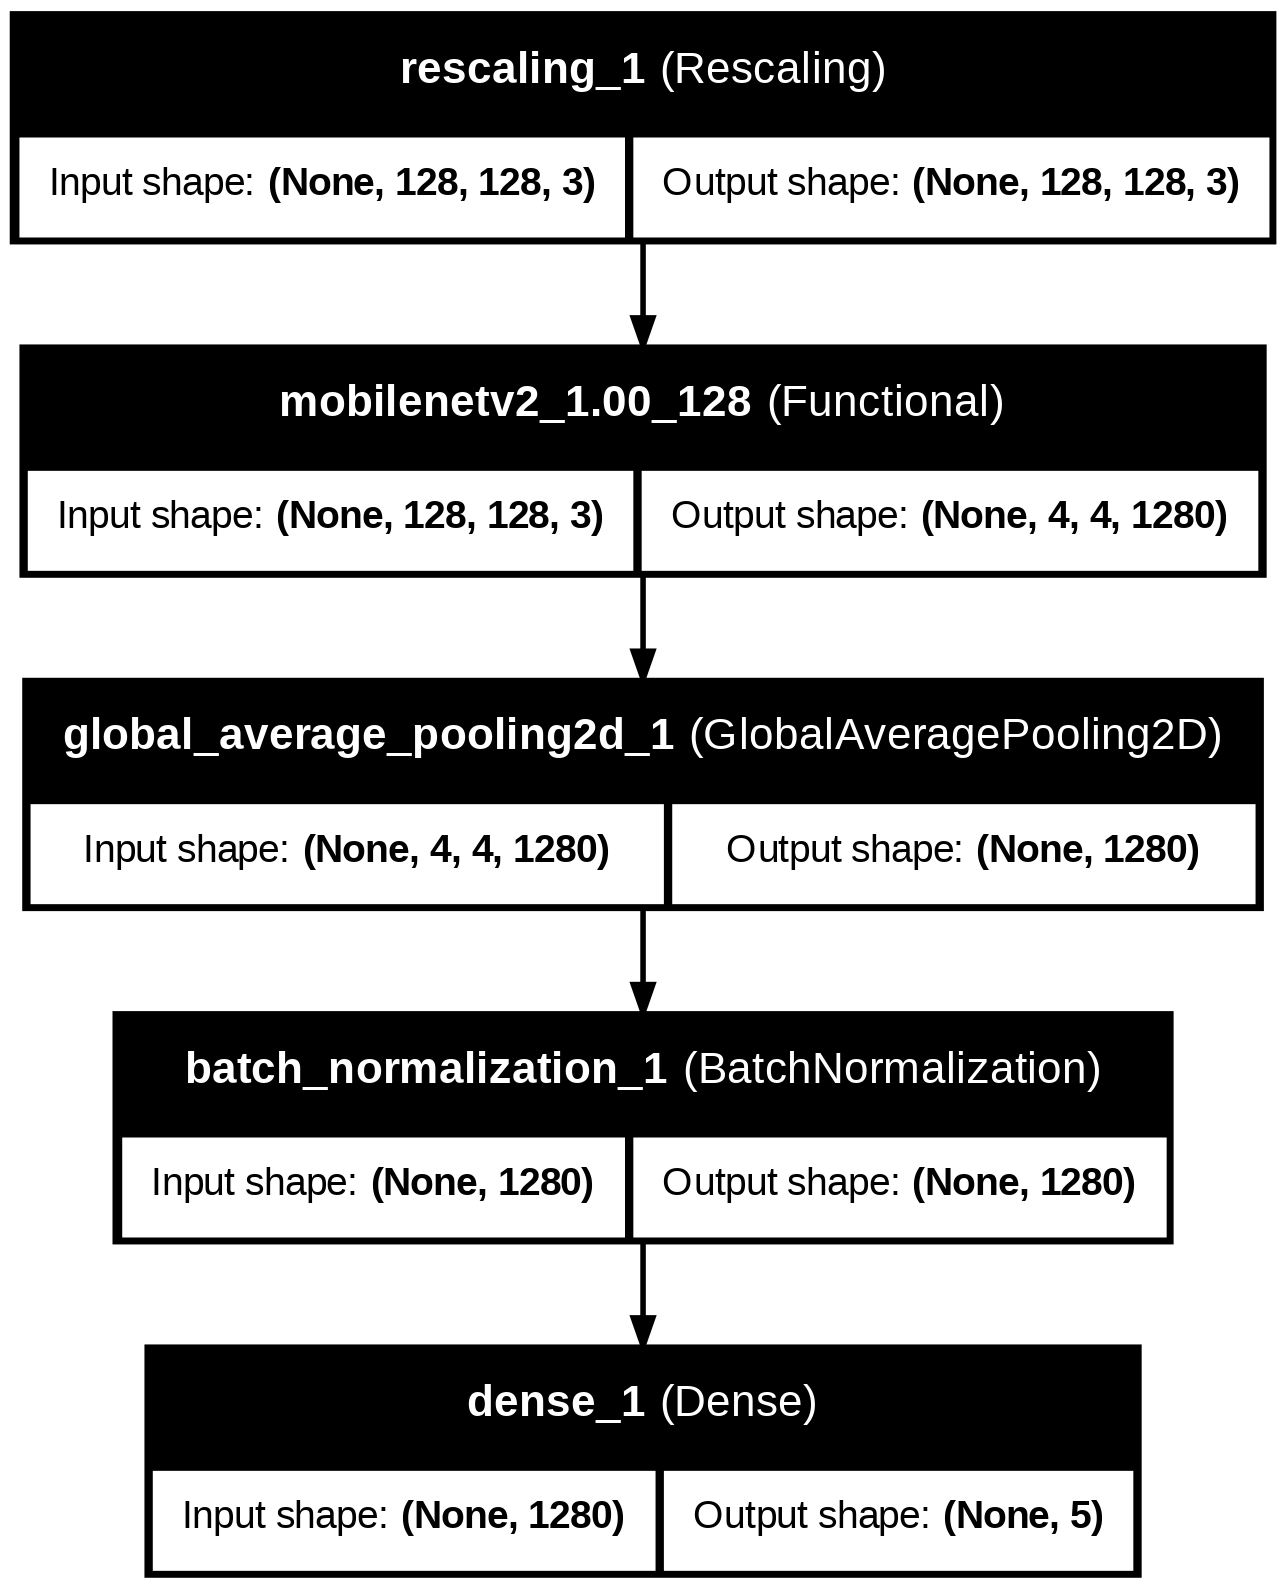

In [36]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file="model_visualization.png")

In [37]:
# 6. Train the model
# Replaced config.epochs with 10, and removed W&B callback
history_finetuning_lr = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 64s 44ms/step - accuracy: 0.7309 - loss: 0.7898 - val_accuracy: 0.7847 - val_loss: 0.6179
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9762 - loss: 0.0926 - val_accuracy: 0.8651 - val_loss: 0.4220
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9983 - loss: 0.0173 - val_accuracy: 0.8787 - val_loss: 0.3804
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9993 - loss: 0.0077 - val_accuracy: 0.8774 - val_loss: 0.3688
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9993 - loss: 0.0050 - val_accuracy: 0.8910 - val_loss: 0.3642
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8951 - val_loss: 0.3642
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8924 - val_loss: 0.3637
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0018 - val_acc

In [38]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(eval_dataset)

# Print the result nicely formatted as a percentage
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8924 - loss: 0.3667
Final Validation Accuracy: 89.24%


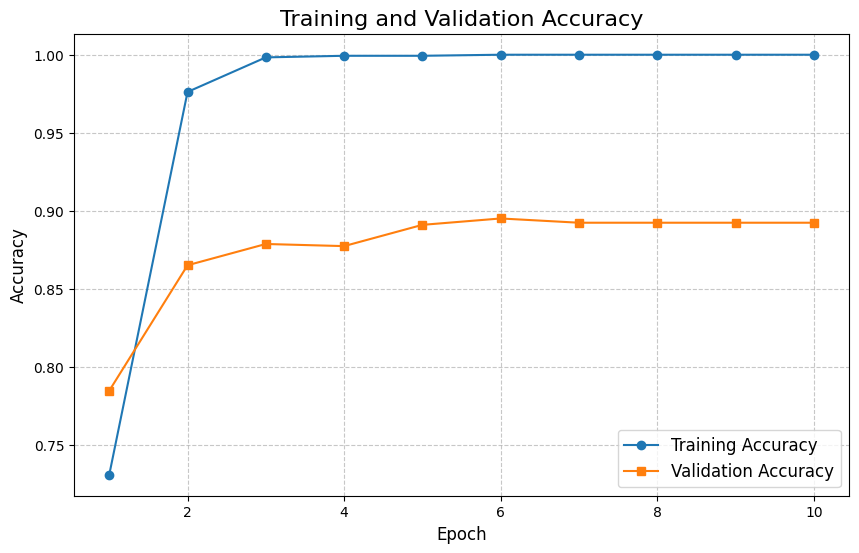

In [39]:
# Extract the metrics from the history object
acc = history_finetuning_lr.history['accuracy']
val_acc = history_finetuning_lr.history['val_accuracy']
epochs_range = range(1, len(acc) + 1) # This sets the x-axis to start at 1

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')

# Add labels and styling
plt.title('Training and Validation Accuracy', fontsize=16)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Transfer learning with fine-tuning + differential learning rate

In [40]:
# 1. Build base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,    
    weights="imagenet"    
)

In [41]:
# We leave it unfrozen for fine-tuning
base_model.trainable = True 

In [42]:
# 2. Build full model
model = keras.Sequential([
    # Add Input layer so plot_model works!
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    # Add Rescaling for MobileNetV2
    keras.layers.Rescaling(1./127.5, offset=-1),
    
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),       
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

In [43]:
# 3. Setup Learning Rate & Compile
# Since differential layer learning rates aren't natively supported in model.fit(), 
# we apply a single, safely small learning rate (1e-5) across the entire unfrozen model.
learning_rate = 1e-5
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

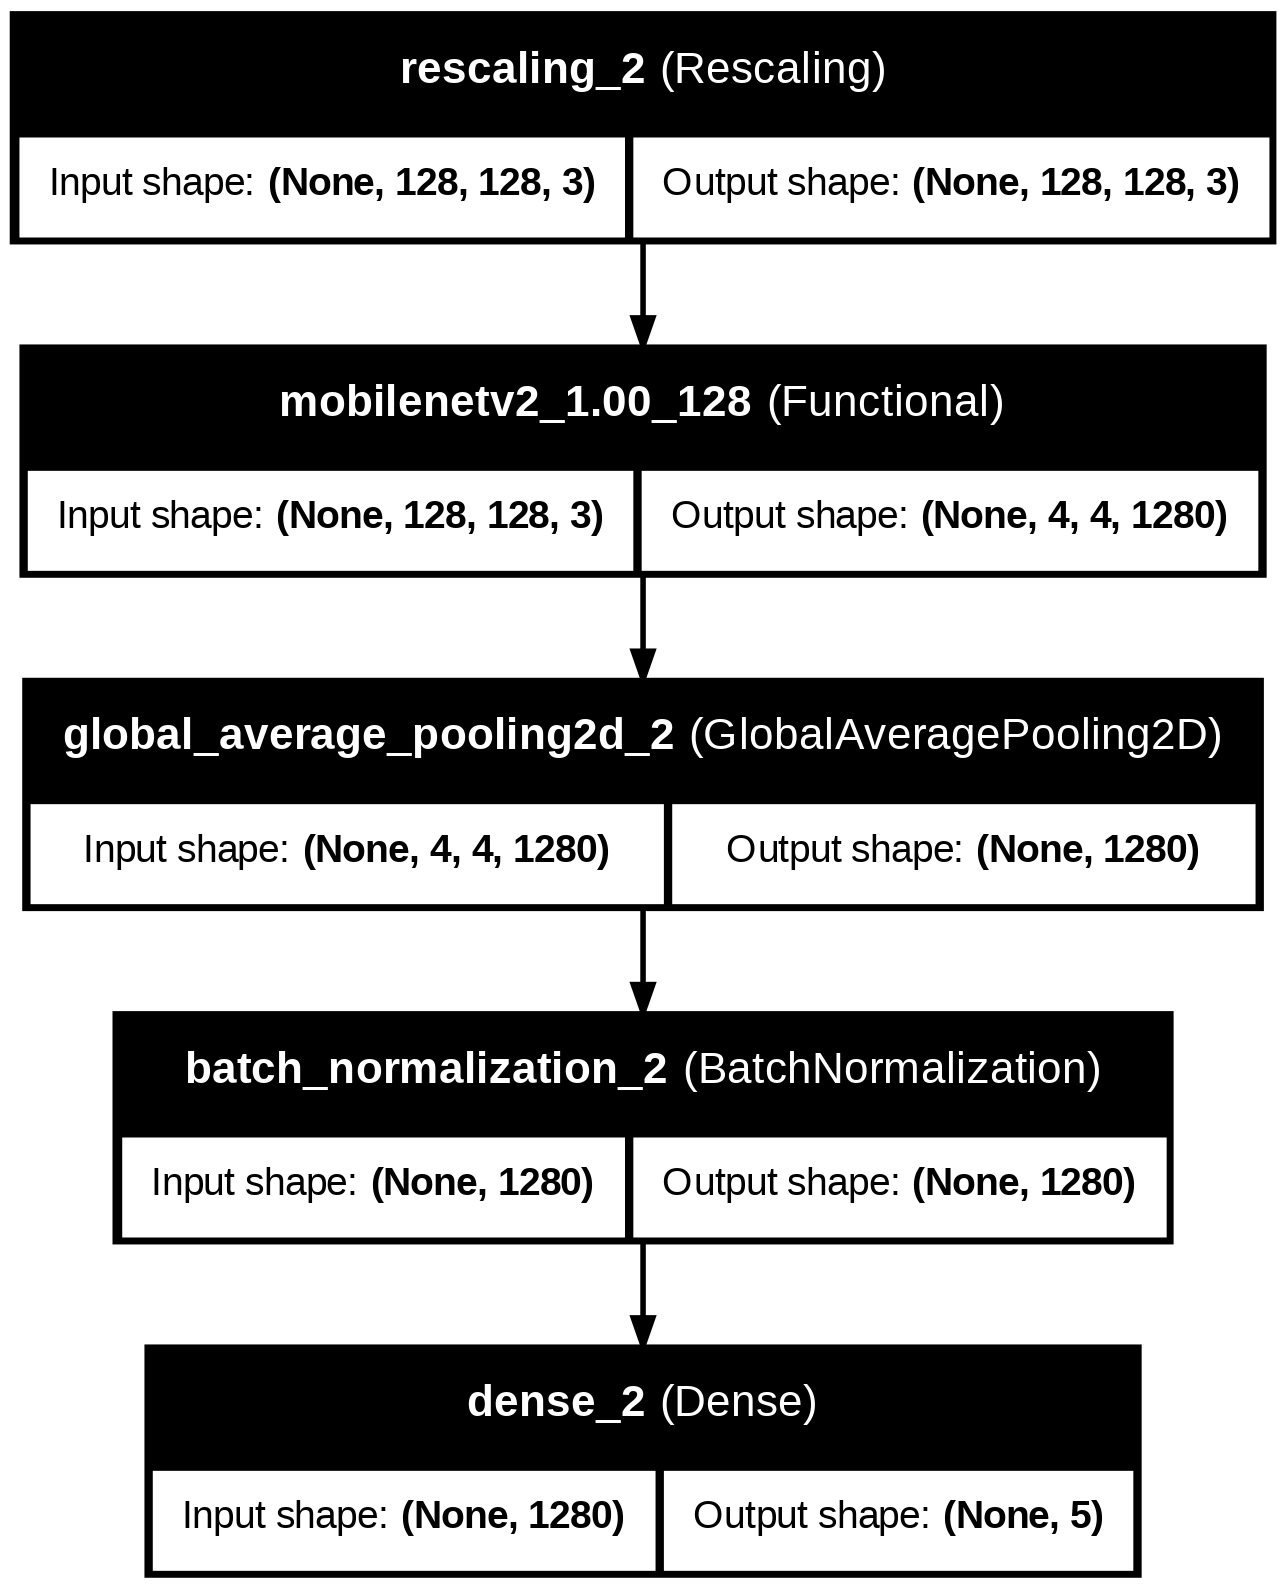

In [45]:
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file="model_visualization.png")

In [46]:
epochs = 10 

history_fine_tuning_dlr = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=epochs
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.4751 - loss: 1.3949 - val_accuracy: 0.5708 - val_loss: 1.1736
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8338 - loss: 0.5049 - val_accuracy: 0.6948 - val_loss: 0.8117
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9533 - loss: 0.2536 - val_accuracy: 0.7575 - val_loss: 0.6606
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9928 - loss: 0.1398 - val_accuracy: 0.7834 - val_loss: 0.5884
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9993 - loss: 0.0864 - val_accuracy: 0.8025 - val_loss: 0.5450
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0587 - val_accuracy: 0.8106 - val_loss: 0.5193
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 1.0000 - loss: 0.0422 - val_accuracy: 0.8147 - val_loss: 0.5030
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0315 - val_acc

In [47]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(eval_dataset)

# Print the result nicely formatted as a percentage
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8311 - loss: 0.4739
Final Validation Accuracy: 83.11%


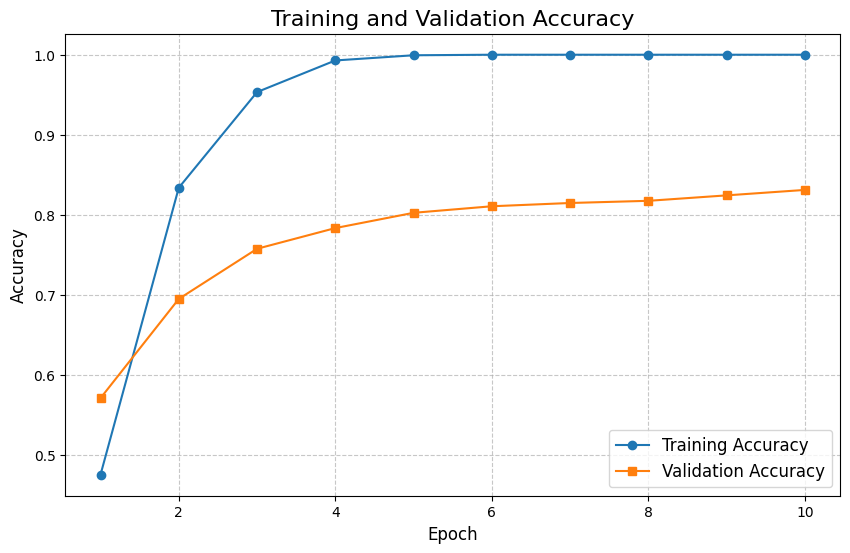

In [48]:
import matplotlib.pyplot as plt

# Extract the metrics from the history object
acc = history_fine_tuning_dlr.history['accuracy']
val_acc = history_fine_tuning_dlr.history['val_accuracy']
epochs_range = range(1, len(acc) + 1) # This sets the x-axis to start at 1

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')

# Add labels and styling
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()